In [1]:
%%capture
!pip install unsloth
!pip install qwen-vl-utils pillow

In [2]:
from unsloth import FastVisionModel
import torch

MODEL_NAME = "sarav7s/qwen3vl-2b-counterfeit-detector"

print("🔄 Loading model...")
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit=True,
    max_seq_length=2048,
)

FastVisionModel.for_inference(model)
print("✅ Model loaded!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
🔄 Loading model...
==((====))==  Unsloth 2026.1.4: Fast Qwen3_Vl patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

✅ Model loaded!


In [3]:
from PIL import Image
from qwen_vl_utils import process_vision_info
import json
import time

# ─── Unified System Prompt ───────────────────────────────────────
SYSTEM_PROMPT = """You are an expert motorcycle parts quality inspector and counterfeit detection specialist.

You can inspect: Helmets, Spark Plugs, Air Filters, Brake Pads, Chains, and any other motorcycle parts.

## CORE RULES:
1. "Cannot see feature" ≠ "Low quality" — NEVER penalize for features not in frame
2. Rate based ONLY on what IS visible
3. Only mark "LOW" if you see ACTUAL defects
4. If truly nothing assessable → "UNCERTAIN"

## INSPECTION PROCESS:

### STEP 1: IDENTIFY THE PART
Determine what motorcycle part is shown in the image.

### STEP 2: CLASSIFY THE VIEW TYPE
- EXTERIOR / INTERIOR / CLOSE_UP / PACKAGING / FULL_PRODUCT / PARTIAL / MIXED

### STEP 3: PART-SPECIFIC ASSESSMENT

**For HELMETS:**
- EXTERIOR: Shell finish, symmetry, visor quality, branding
- INTERIOR: Padding thickness (>25mm=good), strap rivets (metal=good), liner quality
- CLOSE_UP: Text clarity, spelling, certification marks (ISI/DOT/ECE = POSITIVE)
- PACKAGING: Print quality, brand consistency, certification claims

**For SPARK PLUGS:**
- Electrode tip quality, insulator condition, metal shell finish, branding clarity

**For AIR FILTERS:**
- Pleat uniformity (uniform=good, wavy=bad), frame quality, seal/gasket condition, branding

**For BRAKE PADS:**
- Friction material uniformity, backing plate condition, wear indicator presence, branding

**For CHAINS:**
- Link uniformity, roller smoothness, plating evenness, O-ring/X-ring presence, branding

**For ANY OTHER PART:**
- Material quality, manufacturing finish, branding authenticity, safety indicators

### STEP 4: RATING LOGIC
- Visible features look GOOD → "HIGH" (even if other features not visible)
- Visible ACTUAL defects found → "LOW"
- Cannot assess enough → "UNCERTAIN"

## OUTPUT FORMAT (JSON):
{
  "part_type": "HELMET | SPARK_PLUG | AIR_FILTER | BRAKE_PAD | CHAIN | OTHER",
  "view_type": "EXTERIOR | INTERIOR | CLOSE_UP | PACKAGING | FULL_PRODUCT | PARTIAL | MIXED",
  "brand_detected": "string or null",
  "assessed_features": ["list what you COULD assess"],
  "not_in_frame": ["list what you could NOT see - DO NOT PENALIZE THESE"],
  "indicators": {
    "primary_visible_quality": "HIGH | LOW | CANNOT_ASSESS",
    "branding": "PROFESSIONAL | SUSPICIOUS | NONE_VISIBLE",
    "certifications_found": ["list any certs seen"]
  },
  "visible_defects": ["only ACTUAL defects seen - empty if none"],
  "visual_quality": "HIGH | LOW | UNCERTAIN",
  "confidence": 0.0-1.0,
  "reasoning": "Part is [X]. View type is [Y]. Assessed [features]. Quality is [Z] because [reasons]."
}

IMPORTANT: Always respond with valid JSON only. No text before or after the JSON."""


def analyze_part(image, user_question=None):
    """Analyze a motorcycle part image."""
    if image is None:
        return "⚠️ No image provided."

    if user_question is None or not user_question.strip():
        user_question = "Inspect this motorcycle part. Identify the part type, assess quality, and check for signs of counterfeiting."

    start_time = time.time()

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}]
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": user_question},
            ],
        },
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = tokenizer(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            repetition_penalty=1.1,
        )

    generated_ids = output_ids[:, inputs.input_ids.shape[1]:]
    result = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    elapsed = time.time() - start_time
    tokens = generated_ids.shape[1]

    print(f"\n⏱️ {elapsed:.1f}s | 📝 {tokens} tokens | ⚡ {tokens/elapsed:.1f} tok/s")

    try:
        json_start = result.find("{")
        json_end = result.rfind("}") + 1
        if json_start != -1 and json_end > json_start:
            data = json.loads(result[json_start:json_end])
            quality = data.get("visual_quality", "UNKNOWN").upper()
            confidence = data.get("confidence", 0)
            part = data.get("part_type", "UNKNOWN")

            if quality == "HIGH":
                print(f"\n HIGH QUALITY — {part} (Confidence: {confidence:.0%})")
            elif quality == "LOW":
                print(f"\n LOW QUALITY / SUSPECTED COUNTERFEIT — {part} (Confidence: {confidence:.0%})")
            else:
                print(f"\n UNCERTAIN — {part} (Confidence: {confidence:.0%})")

            return json.dumps(data, indent=2, ensure_ascii=False)
    except:
        pass

    return result

print("✅ Inference function ready!")

✅ Inference function ready!


In [9]:
import requests
from io import BytesIO

def test_with_url(image_url, question=None):
    """Quick test with an image URL."""
    print(f"📥 Downloading: {image_url[:60]}...")
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")

    display(image.resize((400, 300)))

    # Analyze
    result = analyze_part(image, question)
    print("\n📋 RESULT:")
    print("─" * 60)
    print(result)

📥 Downloading: https://imgs.search.brave.com/Wt_oCQ-fVLEWU504LeFd74C36TAEYv...


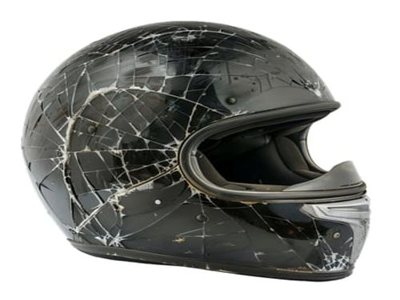


⏱️ 26.6s | 📝 184 tokens | ⚡ 6.9 tok/s

❌ LOW QUALITY / SUSPECTED COUNTERFEIT — HELMET (Confidence: 95%)

📋 RESULT:
────────────────────────────────────────────────────────────
{
  "part_type": "HELMET",
  "view_type": "EXTERIOR",
  "brand_detected": "none_visible",
  "assessed_features": [
    "shell_finish",
    "symmetry",
    "visors_quality",
    "bracing_structure",
    "text_clarity"
  ],
  "not_in_frame": [
    "interior_padding",
    "strap_rivets",
    "liner_material",
    "internal_branding",
    "packaging"
  ],
  "indicators": {
    "primary_visible_quality": "LOW",
    "branding": "NONE_VISIBLE",
    "certifications_found": []
  },
  "visible_defects": [
    "cracked_surface",
    "uneven_paint_application"
  ],
  "visual_quality": "LOW",
  "confidence": 0.95
}


In [10]:
test_with_url("https://imgs.search.brave.com/Wt_oCQ-fVLEWU504LeFd74C36TAEYvtQOS9JZf2FjP0/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly9zdGF0/aWMudmVjdGVlenku/Y29tL3N5c3RlbS9y/ZXNvdXJjZXMvdGh1/bWJuYWlscy8wNTAv/OTY5LzI5Ni9zbWFs/bC9ibGFjay1kYW1h/Z2VkLW1vdG9yY3lj/bGUtaGVsbWV0LXNo/b3dpbmctcm9hZC1y/YXNoLWFmdGVyLWNy/YXNoLXBob3RvLmpw/Zw")